In [1]:
# Load Gold ML tables from MSSQL
import pyodbc
import pandas as pd

from sqlalchemy import create_engine

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=LAMOSKI;"
    "Database=RideMetrics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)
engine = create_engine("mssql+pyodbc://LAMOSKI/RideMetrics?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&encrypt=no")

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone())

df_ml_demand = pd.read_sql(
    'SELECT * FROM Gold.ML_Demand', engine)

df_ml_earnings = pd.read_sql(
    'SELECT * FROM Gold.ML_Earnings', engine)

print(f"Demand shape: {df_ml_demand.shape}")
print(f"Earnings shape: {df_ml_earnings.shape}")

('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tDeveloper Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)
Demand shape: (4287, 17)
Earnings shape: (1561, 12)


DEMAND PREDICTION MODEL

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Encode target variable for demand model using LabelEncoder
target_encoder_demand = LabelEncoder()
df_ml_demand['target'] = target_encoder_demand.fit_transform(
    df_ml_demand['demand_category'])

print(f"Target classes: {target_encoder_demand.classes_}")
print(f"Encoded as: {list(range(len(target_encoder_demand.classes_)))}")

# Define the features and target for the demand model
numerical_features_demand = [
    'hour_minutes',
    'month',
    'distance',
    'duration',
    
]

categorical_features_demand = ['day_of_week', 'season', 'period', 'platform']

x_demand = df_ml_demand[numerical_features_demand + categorical_features_demand]
y_demand = df_ml_demand['target']

print(f"\nX shape: {x_demand.shape}")
print(f"y shape: {y_demand.shape}")

Target classes: ['High' 'Low' 'Medium']
Encoded as: [0, 1, 2]

X shape: (4287, 8)
y shape: (4287,)


Features Splitting and Categorical Encoding 

In [3]:
# Split data before encoding to avoid data leakage
x_demand_train, x_demand_test, y_demand_train, y_demand_test = train_test_split(
    x_demand, y_demand,
    test_size=0.2,
    random_state=42,
    stratify=y_demand
)

print(f"Training set: {x_demand_train.shape}")
print(f"Test set:     {x_demand_test.shape}")

# Initialize encoders for categorical features
day_encoder_demand = OneHotEncoder(sparse_output=False, drop='first')
season_encoder_demand = OneHotEncoder(sparse_output=False, drop='first')
period_encoder_demand = OneHotEncoder(sparse_output=False, drop='first')
platform_encoder_demand = OneHotEncoder(sparse_output=False, drop='first')

# Fit on training data only → transform both train and test
# fit_transform → training data only
# transform → test data only (no fit — prevents leakage)
day_train_demand = day_encoder_demand.fit_transform(x_demand_train[['day_of_week']])
season_train_demand = season_encoder_demand.fit_transform(x_demand_train[['season']])
period_train_demand = period_encoder_demand.fit_transform(x_demand_train[['period']])
platform_train_demand = platform_encoder_demand.fit_transform(x_demand_train[['platform']])

day_test_demand = day_encoder_demand.transform(x_demand_test[['day_of_week']])
season_test_demand = season_encoder_demand.transform(x_demand_test[['season']])
period_test_demand = period_encoder_demand.transform(x_demand_test[['period']])
platform_test_demand = platform_encoder_demand.transform(x_demand_test[['platform']])

# Get encoded column names
day_cols_demand = list(day_encoder_demand.get_feature_names_out())
season_cols_demand = list(season_encoder_demand.get_feature_names_out())
period_cols_demand = list(period_encoder_demand.get_feature_names_out())
platform_cols_demand = list(platform_encoder_demand.get_feature_names_out())

# Build final train and test sets
x_demand_train_final = pd.concat([
    x_demand_train[numerical_features_demand].reset_index(drop=True),
    pd.DataFrame(day_train_demand, columns=day_cols_demand),
    pd.DataFrame(season_train_demand, columns=season_cols_demand),
    pd.DataFrame(period_train_demand, columns=period_cols_demand),
    pd.DataFrame(platform_train_demand, columns=platform_cols_demand)
], axis=1)

x_demand_test_final = pd.concat([
    x_demand_test[numerical_features_demand].reset_index(drop=True),
    pd.DataFrame(day_test_demand, columns=day_cols_demand),
    pd.DataFrame(season_test_demand, columns=season_cols_demand),
    pd.DataFrame(period_test_demand, columns=period_cols_demand),
    pd.DataFrame(platform_test_demand, columns=platform_cols_demand)
], axis=1)

print(f"\nX_train_final shape: {x_demand_train_final.shape}")
print(f"X_test_final shape:  {x_demand_test_final.shape}")
print(f"\nAll features: {x_demand_train_final.columns.tolist()}")

Training set: (3429, 8)
Test set:     (858, 8)

X_train_final shape: (3429, 18)
X_test_final shape:  (858, 18)

All features: ['hour_minutes', 'month', 'distance', 'duration', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter', 'period_Evening', 'period_Midnight', 'period_Morning', 'period_Night', 'platform_Uber']


Correlation Matrix

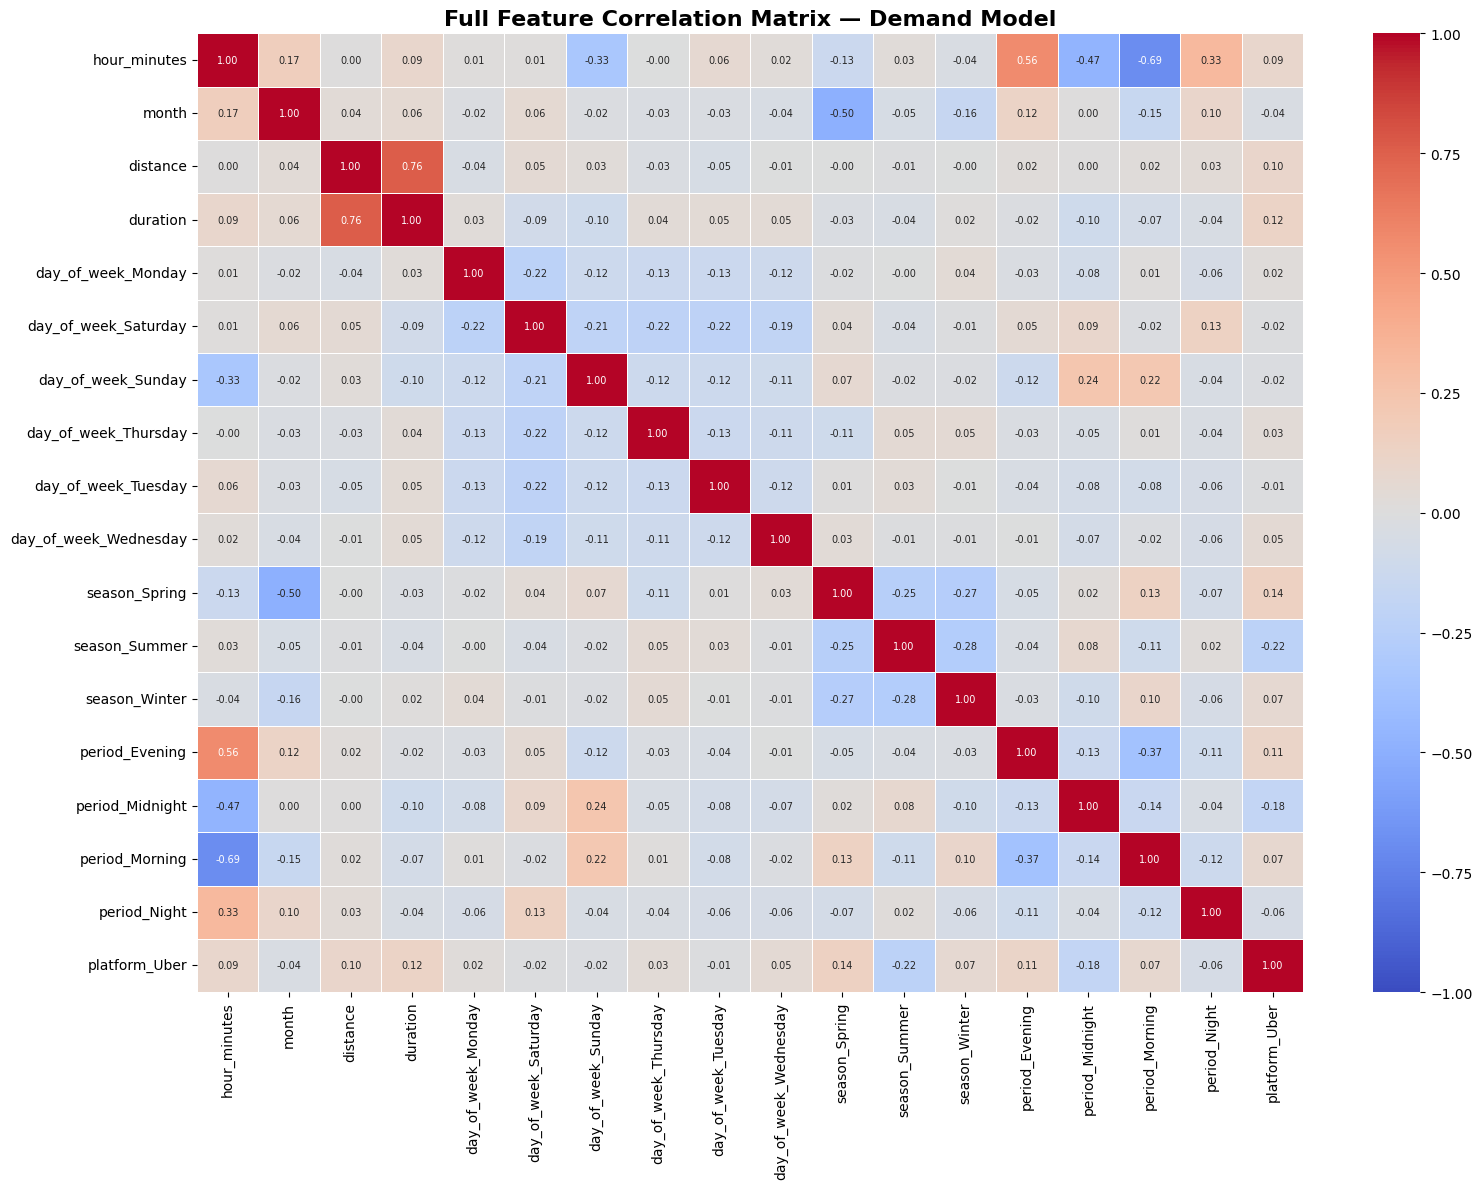


Correlations with demand target (strongest first):
season_Spring            0.251
season_Summer            0.213
day_of_week_Wednesday    0.193
day_of_week_Saturday     0.112
period_Evening           0.110
period_Night             0.083
distance                 0.034
period_Morning           0.034
period_Midnight          0.028
hour_minutes             0.010
platform_Uber            0.006
day_of_week_Sunday      -0.006
duration                -0.067
day_of_week_Tuesday     -0.106
day_of_week_Thursday    -0.117
day_of_week_Monday      -0.119
month                   -0.135
season_Winter           -0.230
Name: target, dtype: float64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# correlation matrix on numerical features only
# categorical features are encoded and included separately
corr = x_demand_train_final.corr()

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_title('Full Feature Correlation Matrix — Demand Model',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations with target
print("\nCorrelations with demand target (strongest first):")
corr_with_target = pd.concat([
    x_demand_train_final,
    y_demand_train.reset_index(drop=True)
], axis=1).corr()['target'].drop('target').sort_values(
    ascending=False)
print(corr_with_target.round(3))

Model Training

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Scale for Logistic Regression only
scaler_demand = StandardScaler()
x_demand_train_scaled = scaler_demand.fit_transform(x_demand_train_final)
x_demand_test_scaled = scaler_demand.transform(x_demand_test_final)

# Logistic Regression — uses scaled data
lr_model_demand = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
lr_model_demand.fit(x_demand_train_scaled, y_demand_train)
print("Logistic Regression trained!")

# Random Forest — uses unscaled data
rf_model_demand = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model_demand.fit(x_demand_train_final, y_demand_train)
print("Random Forest trained!")

# XGBoost — uses unscaled data
xgb_model_demand = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model_demand.fit(x_demand_train_final, y_demand_train)
print("XGBoost trained!")

# Evaluate all three models
models_demand = {
    'Logistic Regression': (lr_model_demand, x_demand_test_scaled),
    'Random Forest': (rf_model_demand, x_demand_test_final),
    'XGBoost': (xgb_model_demand, x_demand_test_final)
}

results_demand = []
for name, (model, x_test_data) in models_demand.items():
    y_pred = model.predict(x_test_data)
    results_demand.append({
        'Model': name,
        'Accuracy': accuracy_score(y_demand_test, y_pred),
        'F1-Score': f1_score(y_demand_test, y_pred, average='weighted')
    })

print("\nModel Evaluation Results:")
print(pd.DataFrame(results_demand).set_index('Model').round(4))

Logistic Regression trained!
Random Forest trained!
XGBoost trained!

Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.7308    0.7287
Random Forest          0.7890    0.7902
XGBoost                0.9627    0.9600


Confusion Matrix, Classification Report and Shap Importance Features

c:\Users\olami\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classification Report — XGBoost:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       246
         Low       0.97      0.69      0.80        96
      Medium       0.94      1.00      0.97       516

    accuracy                           0.96       858
   macro avg       0.97      0.89      0.92       858
weighted avg       0.96      0.96      0.96       858



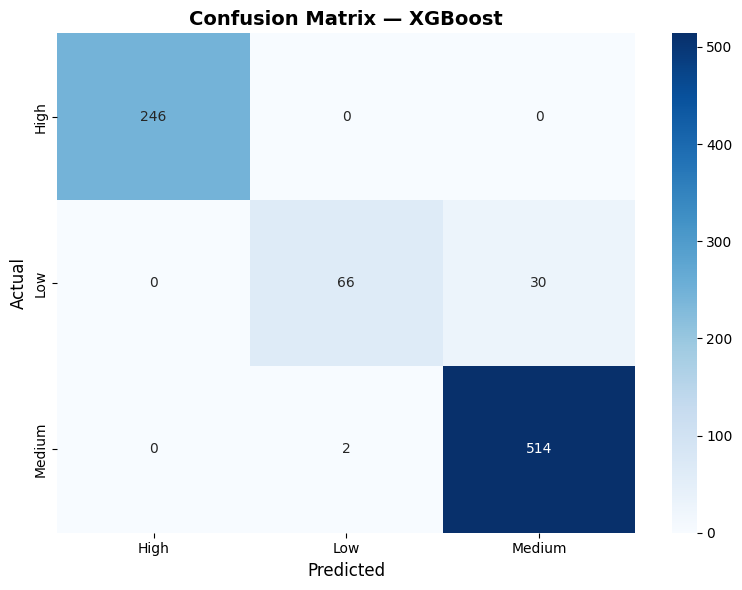

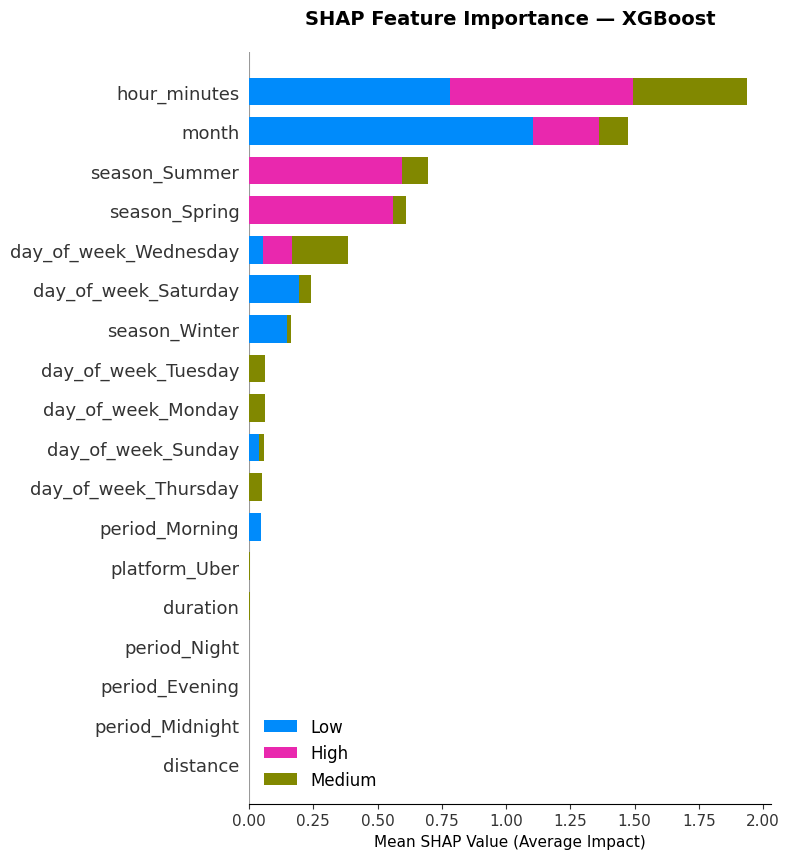


CV F1 Scores: [0.9673 0.9521 0.9645 0.9308 0.9656]
Mean: 0.9561
Std:  0.0137


In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import cross_val_score

# Best Model: XGBoost
y_pred_xgb_demand = xgb_model_demand.predict(x_demand_test_final)

# Classification Report
print("Classification Report — XGBoost:")
print(classification_report(
    y_demand_test,
    y_pred_xgb_demand,
    target_names=target_encoder_demand.classes_
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_demand_test, y_pred_xgb_demand)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder_demand.classes_,
    yticklabels=target_encoder_demand.classes_,
    ax=ax
)
ax.set_title('Confusion Matrix — XGBoost',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# SHAP Explainer for XGBoost
explainer_xgb_demand = shap.TreeExplainer(xgb_model_demand)
shap_values_xgb_demand = explainer_xgb_demand.shap_values(x_demand_test_final)

# SHAP Summary Plot — Overall Feature Importance
shap.summary_plot(
    shap_values_xgb_demand,
    x_demand_test_final,
    feature_names=x_demand_train_final.columns.tolist(),
    plot_type="bar",
    show=False,
    class_names=target_encoder_demand.classes_.tolist()
)
plt.title("SHAP Feature Importance — XGBoost",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean SHAP Value (Average Impact)", fontsize=11)
plt.tight_layout()
plt.show()

# Cross Validation
cv_scores_demand = cross_val_score(
    xgb_model_demand,
    x_demand_train_final,
    y_demand_train,
    cv=5,
    scoring='f1_weighted'
)
print(f"\nCV F1 Scores: {cv_scores_demand.round(4)}")
print(f"Mean: {cv_scores_demand.mean():.4f}")
print(f"Std:  {cv_scores_demand.std():.4f}")

In [7]:
import numpy as np

# Calculate mean SHAP values correctly for multiclass
if isinstance(shap_values_xgb_demand, list):
    mean_shap_demand = np.mean(
        [abs(sv).mean(axis=0) for sv in shap_values_xgb_demand],
        axis=0
    )
elif shap_values_xgb_demand.ndim == 3:
    mean_shap_demand = abs(shap_values_xgb_demand).mean(axis=(0, 2))
else:
    mean_shap_demand = abs(shap_values_xgb_demand).mean(axis=0)

# Create feature importance dataframe
feature_importance_demand = pd.DataFrame({
    'Feature': x_demand_train_final.columns.tolist(),
    'Mean SHAP': mean_shap_demand.flatten()
}).sort_values('Mean SHAP', ascending=False)

print("Feature Importance by SHAP:")
print(feature_importance_demand.reset_index(drop=True).to_string())

Feature Importance by SHAP:
                  Feature  Mean SHAP
0            hour_minutes   0.645130
1                   month   0.491009
2           season_Summer   0.231759
3           season_Spring   0.203928
4   day_of_week_Wednesday   0.127939
5    day_of_week_Saturday   0.079888
6           season_Winter   0.054534
7     day_of_week_Tuesday   0.021197
8      day_of_week_Monday   0.020401
9      day_of_week_Sunday   0.019903
10   day_of_week_Thursday   0.016584
11         period_Morning   0.015576
12          platform_Uber   0.001109
13               duration   0.000630
14               distance   0.000000
15         period_Evening   0.000000
16        period_Midnight   0.000000
17           period_Night   0.000000


Retraining with Optimized Features

In [8]:
# Keeping only the most important features based on SHAP values and correlation analysis
features_demand_optimized = [
    'hour_minutes',
    'month'
]

# Day columns to keep based on SHAP analysis
day_cols_keep = [
    'day_of_week_Wednesday',
    'day_of_week_Saturday',
    'day_of_week_Tuesday',
    'day_of_week_Monday',
    'day_of_week_Sunday',
    'day_of_week_Thursday'
]

# Season columns to keep based on SHAP analysis
season_cols_keep = [
    'season_Summer',
    'season_Spring',
    'season_Winter'
]

# Period columns to keep based on SHAP analysis
period_cols_keep_demand = ['period_Morning']

features_demand_final_optimized = (
    features_demand_optimized +
    day_cols_keep +
    season_cols_keep +
    period_cols_keep_demand
)

X_demand_opt = x_demand_train_final[features_demand_final_optimized]
X_demand_test_opt = x_demand_test_final[features_demand_final_optimized]

# Retraining XGBoost with optimized features
xgb_demand_optimized = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_demand_optimized.fit(X_demand_opt, y_demand_train)

y_pred_demand_opt = xgb_demand_optimized.predict(X_demand_test_opt)
print(f"Optimized Accuracy: {accuracy_score(y_demand_test, y_pred_demand_opt):.4f}")
print(f"Optimized F1:       {f1_score(y_demand_test, y_pred_demand_opt, average='weighted'):.4f}")

Optimized Accuracy: 0.9650
Optimized F1:       0.9627


Cross Validation Score


In [20]:
# cross-validation on the entire dataset with optimized features
X_demand_all = pd.concat([
    x_demand_train_final[features_demand_final_optimized],
    x_demand_test_final[features_demand_final_optimized]
]).reset_index(drop=True)

y_demand_all = pd.concat([
    y_demand_train,
    y_demand_test
]).reset_index(drop=True)

cv_scores_opt = cross_val_score(
    xgb_demand_optimized,
    X_demand_all,
    y_demand_all,
    cv=5,
    scoring='f1_weighted'
)
print(f"CV F1: {cv_scores_opt.round(4)}")
print(f"Mean: {cv_scores_opt.mean():.4f}")
print(f"Std:  {cv_scores_opt.std():.4f}")

CV F1: [0.9605 0.9771 0.9649 0.9649 0.9595]
Mean: 0.9654
Std:  0.0063


EARNINGS PREDICTION MODEL


In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split


# Encode target variable for earnings model using LabelEncoder
target_encoder2 = LabelEncoder()
df_ml_earnings['target'] = target_encoder2.fit_transform(
    df_ml_earnings['earning_category'])

print(f"Target classes: {target_encoder2.classes_}")
print(f"Encoded as: {list(range(len(target_encoder2.classes_)))}")



# Define the features and target for the earnings model
numerical_features = [
    'hour_minutes',
    'month',
    'avg_distance_km',
    'avg_duration_minutes',
    'total_trips',
    'demand_score',
    'is_event_day'
]

categorical_features = ['day_of_week', 'season', 'period']

x_earning = df_ml_earnings[numerical_features + categorical_features]
y_earning = df_ml_earnings['target']


print(f"\nX shape: {x_earning.shape}")
print(f"y shape: {y_earning.shape}")



Target classes: ['High' 'Low' 'Medium']
Encoded as: [0, 1, 2]

X shape: (1561, 10)
y shape: (1561,)


Features Splitting

In [11]:
x_earning_train, x_earning_test, y_earning_train, y_earning_test = train_test_split(
    x_earning, y_earning, test_size=0.2, random_state=42, stratify=y_earning
)
print(f"\nTraining set: {x_earning_train.shape}")
print(f"Test set:     {x_earning_test.shape}")


Training set: (1248, 10)
Test set:     (313, 10)


Categorical Features Encoding

In [12]:
# Encode categorical features using OneHotEncoder
day_encoder = OneHotEncoder(sparse_output=False, drop='first')
season_encoder = OneHotEncoder(sparse_output=False, drop='first')
period_encoder = OneHotEncoder(sparse_output=False, drop='first')

# Transform categorical features in the training set
day_train = day_encoder.fit_transform(x_earning_train[['day_of_week']])
season_train = season_encoder.fit_transform(x_earning_train[['season']])
period_train = period_encoder.fit_transform(x_earning_train[['period']])

# Transform categorical features in the test set
day_test = day_encoder.transform(x_earning_test[['day_of_week']])
season_test = season_encoder.transform(x_earning_test[['season']])
period_test = period_encoder.transform(x_earning_test[['period']])

# Extracting the encoded column names for each categorical feature
day_cols = list(day_encoder.get_feature_names_out())
season_cols = list(season_encoder.get_feature_names_out())
period_cols = list(period_encoder.get_feature_names_out())

# Finalizing the training and test sets by combining numerical and encoded categorical features
x_earning_train_final = pd.concat([
    x_earning_train[numerical_features].reset_index(drop=True),
    pd.DataFrame(day_train, columns=day_cols),
    pd.DataFrame(season_train, columns=season_cols),
    pd.DataFrame(period_train, columns=period_cols)
], axis=1)
x_earning_test_final = pd.concat([
    x_earning_test[numerical_features].reset_index(drop=True),
    pd.DataFrame(day_test, columns=day_cols),
    pd.DataFrame(season_test, columns=season_cols),
    pd.DataFrame(period_test, columns=period_cols)
], axis=1)

print(f"\nX_train_final shape: {x_earning_train_final.shape}")
print(f"X_test_final shape:  {x_earning_test_final.shape}")
print(f"\nAll features: {x_earning_train_final.columns.tolist()}")


X_train_final shape: (1248, 20)
X_test_final shape:  (313, 20)

All features: ['hour_minutes', 'month', 'avg_distance_km', 'avg_duration_minutes', 'total_trips', 'demand_score', 'is_event_day', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter', 'period_Evening', 'period_Midnight', 'period_Morning', 'period_Night']


Correlation Matrix

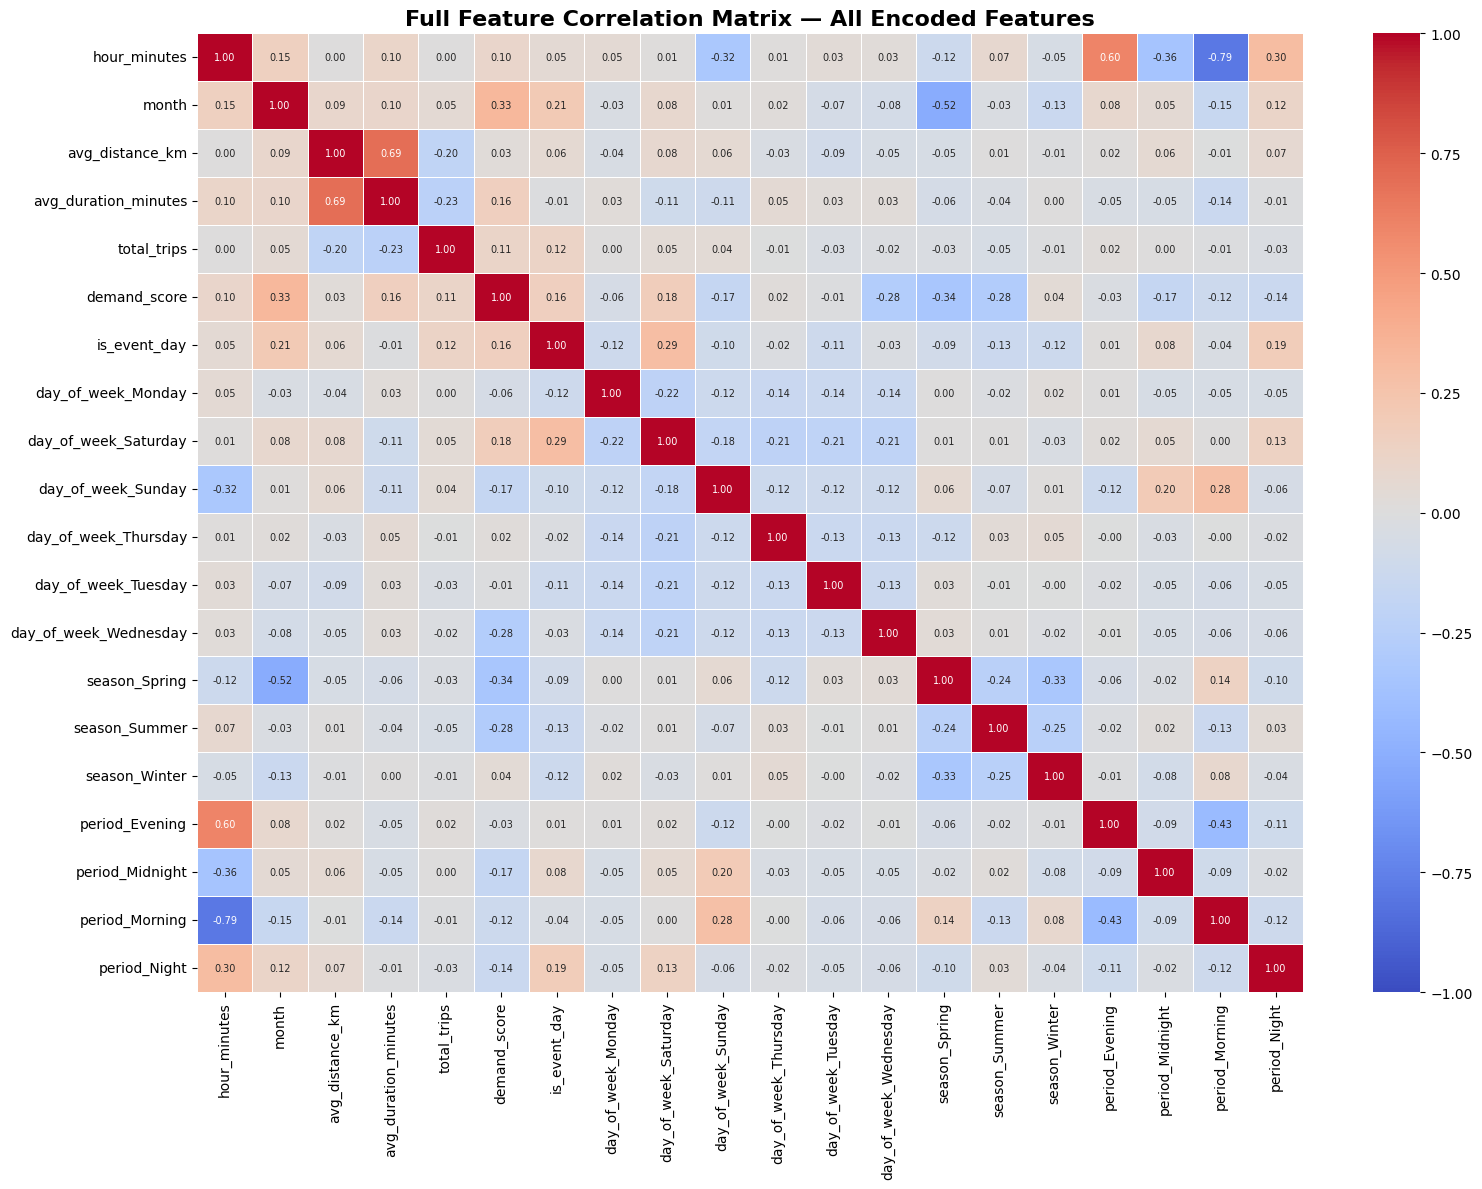

                       hour_minutes  month  avg_distance_km  \
hour_minutes                  1.000  0.154            0.001   
month                         0.154  1.000            0.093   
avg_distance_km               0.001  0.093            1.000   
avg_duration_minutes          0.104  0.100            0.694   
total_trips                   0.002  0.054           -0.196   
demand_score                  0.098  0.328            0.029   
is_event_day                  0.050  0.207            0.056   
day_of_week_Monday            0.050 -0.034           -0.042   
day_of_week_Saturday          0.009  0.079            0.077   
day_of_week_Sunday           -0.323  0.008            0.056   
day_of_week_Thursday          0.015  0.022           -0.034   
day_of_week_Tuesday           0.034 -0.065           -0.093   
day_of_week_Wednesday         0.030 -0.077           -0.051   
season_Spring                -0.122 -0.519           -0.054   
season_Summer                 0.071 -0.025            0

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Build encoded dataframe for correlation
corr = x_earning_train_final.corr()

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_title('Full Feature Correlation Matrix — All Encoded Features',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations
print(corr.round(3))

Model Training

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Scale for Logistic Regression only
scaler = StandardScaler()
x_train_scaled_earnings = scaler.fit_transform(x_earning_train_final)
x_test_scaled_earnings = scaler.transform(x_earning_test_final)

# Logistic Regression — uses scaled data
lr_model_earnings = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
lr_model_earnings.fit(x_train_scaled_earnings, y_earning_train)

# Random Forest — uses unscaled data
rf_model_earnings = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model_earnings.fit(x_earning_train_final, y_earning_train)

# XGBoost — uses unscaled data
xgb_model_earnings = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model_earnings.fit(x_earning_train_final, y_earning_train)

# Evaluate all three models
models = {
    'Logistic Regression': (lr_model_earnings, x_test_scaled_earnings),
    'Random Forest': (rf_model_earnings, x_earning_test_final),
    'XGBoost': (xgb_model_earnings, x_earning_test_final)
}

results = []
for name, (model, x_test_data) in models.items():
    y_pred = model.predict(x_test_data)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_earning_test, y_pred),
        'F1-Score': f1_score(y_earning_test, y_pred, average='weighted')
    })

print("\nModel Evaluation Results:")
print(pd.DataFrame(results).set_index('Model').round(4))


Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.7668    0.7687
Random Forest          0.7508    0.7428
XGBoost                0.7412    0.7398


Confusion Matrix, Classification Report and Shap Importance Features

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

        High       0.86      0.78      0.81       107
         Low       0.82      0.83      0.83       103
      Medium       0.64      0.69      0.66       103

    accuracy                           0.77       313
   macro avg       0.77      0.77      0.77       313
weighted avg       0.77      0.77      0.77       313



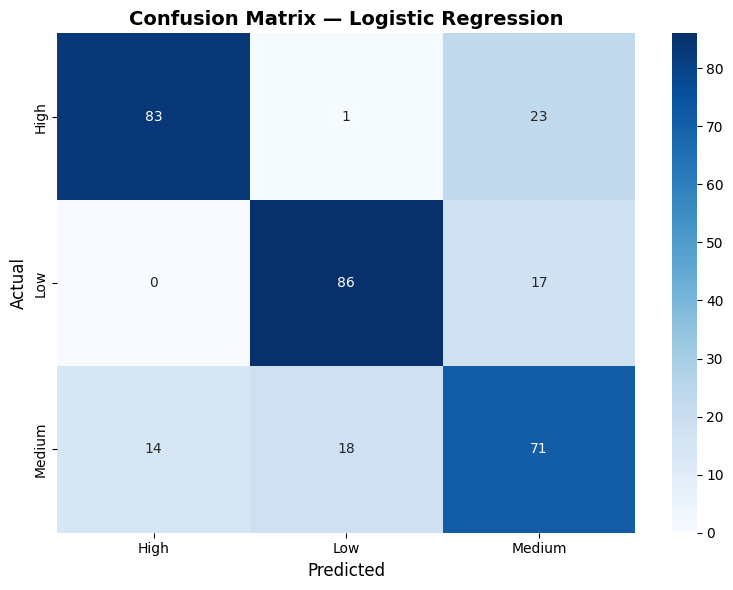

Background dataset has 1248 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1248 when initializing the masker.


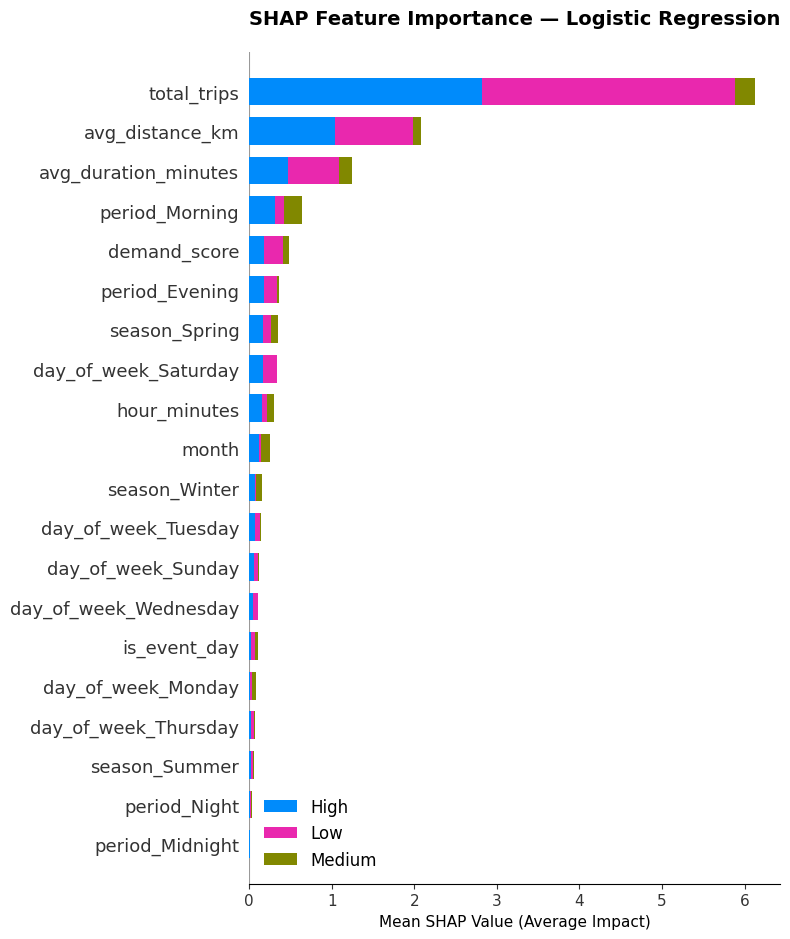

In [15]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import cross_val_score

# Best Model: Logistic Regression
y_pred_lr = lr_model_earnings.predict(x_test_scaled_earnings)

# Classification Report
print("Classification Report — Logistic Regression:")
print(classification_report(
    y_earning_test,
    y_pred_lr,
    target_names=target_encoder2.classes_
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_earning_test, y_pred_lr)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder2.classes_,
    yticklabels=target_encoder2.classes_,
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# SHAP Explainer for Logistic Regression
explainer_lr = shap.LinearExplainer(
    lr_model_earnings,
    x_train_scaled_earnings
)
shap_values_lr = explainer_lr.shap_values(x_test_scaled_earnings)

# SHAP Summary Plot — Overall Feature Importance
shap.summary_plot(
    shap_values_lr,
    x_test_scaled_earnings,
    feature_names=x_earning_train_final.columns.tolist(),
    plot_type="bar",
    show=False,
    class_names=target_encoder2.classes_.tolist()
)
plt.title("SHAP Feature Importance — Logistic Regression",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean SHAP Value (Average Impact)", fontsize=11)
plt.tight_layout()
plt.show()



Retraining with Optimized Features


In [16]:
# Keeping only the most important features based on SHAP values and correlation analysis
features_optimized = [
    'total_trips',
    'avg_distance_km',
    'avg_duration_minutes',
    'demand_score'
]

# Period columns to keep based on correlation analysis
period_cols_keep = ['period_Morning', 'period_Evening']

features_final_optimized = features_optimized + period_cols_keep

X_opt = x_earning_train_final[features_final_optimized]
X_test_opt = x_earning_test_final[features_final_optimized]

# Scale
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)

# Retraining Logistic Regression with optimized features
lr_optimized = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
lr_optimized.fit(X_train_opt_scaled, y_earning_train)

y_pred_opt = lr_optimized.predict(X_test_opt_scaled)
print(f"Optimized Accuracy: {accuracy_score(y_earning_test, y_pred_opt):.4f}")
print(f"Optimized F1: {f1_score(y_earning_test, y_pred_opt, average='weighted'):.4f}")

Optimized Accuracy: 0.7700
Optimized F1: 0.7719


Cross Validation Score

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_optimized,
    X_train_opt_scaled,
    y_earning_train,
    cv=5,
    scoring='f1_weighted'
)
print(f"CV F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")

CV F1 Scores: [0.805  0.8122 0.7589 0.7957 0.7755]
Mean: 0.7895
Std:  0.0196
